# Logistic Regression

## 1 Nạp thư viện

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Nạp dữ liệu

In [25]:
dataset = pd.read_csv('/content/breast_cancer.csv')
dataset.head(5)

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [26]:
dataset.describe()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.830000e+02,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,1.076720e+06,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,6.206440e+05,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,6.337500e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.776170e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171795e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238705e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [27]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample code number           683 non-null    int64
 1   Clump Thickness              683 non-null    int64
 2   Uniformity of Cell Size      683 non-null    int64
 3   Uniformity of Cell Shape     683 non-null    int64
 4   Marginal Adhesion            683 non-null    int64
 5   Single Epithelial Cell Size  683 non-null    int64
 6   Bare Nuclei                  683 non-null    int64
 7   Bland Chromatin              683 non-null    int64
 8   Normal Nucleoli              683 non-null    int64
 9   Mitoses                      683 non-null    int64
 10  Class                        683 non-null    int64
dtypes: int64(11)
memory usage: 58.8 KB


## 4. Tiền xử lý dữ liệu

In [28]:
dataset = dataset.drop(columns=['Sample code number'])
dataset.head(5)

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


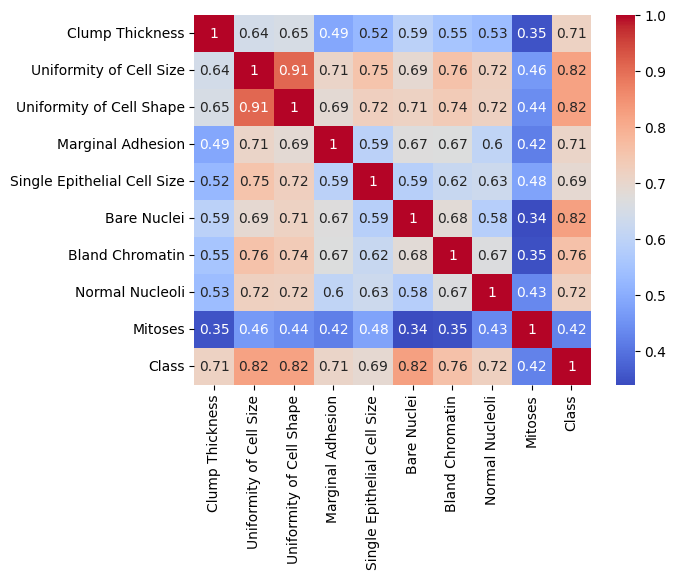

In [29]:
## Kiểm tra ma trận tương quan
corr_matrix = dataset.corr()

sns.heatmap(corr_matrix, annot=True,cmap='coolwarm')
plt.show()

In [30]:
## Tính VIF để phát hiện đa cộng tuyến
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [31]:
X = dataset.drop('Class', axis=1)
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

                       Feature        VIF
0              Clump Thickness   5.194380
1      Uniformity of Cell Size  13.991156
2     Uniformity of Cell Shape  14.131730
3            Marginal Adhesion   4.874432
4  Single Epithelial Cell Size   6.879037
5                  Bare Nuclei   4.984470
6              Bland Chromatin   7.526238
7              Normal Nucleoli   4.534766
8                      Mitoses   2.560638


In [32]:
#Loại bỏ biến có tương quan cao
dataset = dataset.drop(columns=['Uniformity of Cell Shape'])
dataset.head(5)

,Clump Thickness,Uniformity of Cell Size,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,2,1,3,1,1,2
1,5,4,5,7,10,3,2,1,2
2,3,1,1,2,2,3,1,1,2
3,6,8,1,3,4,3,7,1,2
4,4,1,3,2,1,3,1,1,2


In [33]:
#Kiểm tra thuộc tính class
dataset['Class'].unique()

array([2, 4])

In [34]:
#Biến đổi 2:0 , 4:1
dataset['Class'] = dataset['Class'].map({2: 0, 4: 1})
dataset.head(5)

,Clump Thickness,Uniformity of Cell Size,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,2,1,3,1,1,0
1,5,4,5,7,10,3,2,1,0
2,3,1,1,2,2,3,1,1,0
3,6,8,1,3,4,3,7,1,0
4,4,1,3,2,1,3,1,1,0


## 5. Tách biến độc lập, biến phụ thuộc

In [35]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]


In [36]:
print(X)

     Clump Thickness  Uniformity of Cell Size  Marginal Adhesion  \
0                  5                        1                  1   
1                  5                        4                  5   
2                  3                        1                  1   
3                  6                        8                  1   
4                  4                        1                  3   
..               ...                      ...                ...   
678                3                        1                  1   
679                2                        1                  1   
680                5                       10                  3   
681                4                        8                  4   
682                4                        8                  5   

     Single Epithelial Cell Size  Bare Nuclei  Bland Chromatin  \
0                              2            1                3   
1                              7           10      

## 6. Chia tập huấn luyện, tập kiểm thử

In [37]:
from sklearn.model_selection import train_test_split

# Chia tập huấn luyện và kiểm thử
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [38]:
print(X_train.shape)

(546, 8)


In [39]:
#Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 7. Huấn luyện mô hình

In [40]:
from sklearn.linear_model import LogisticRegression
regressor = LogisticRegression()
regressor.fit(X_train,y_train)


LogisticRegression()

In [41]:
y_pred = regressor.predict(X_test)
#
print(y_test.head(5))
print(y_pred[:5])

113    0
378    0
303    1
504    1
301    0
Name: Class, dtype: int64
[0 0 1 1 0]


## 8. Đánh giá mô hình

In [42]:
# sử dụng các chỉ số
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.9416058394160584
Precision: 0.92
Recall: 0.92
F1 score: 0.92


In [43]:
#sử dụng ma trận nhầm lẫn
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[83  4]
 [ 4 46]]


## Sử dụng độ đo ROC

In [44]:
# Sử dụng phương thức predict_proba từ đối tượng regressor
y_prob = regressor.predict_proba(X_test)[:,1]
print(y_prob)

[0.0078996  0.00628799 0.90543302 0.97489332 0.00174992 0.00581805
 0.0260155  0.99946867 0.00462849 0.00264678 0.99944621 0.01919168
 0.99997957 0.00628799 0.03973479 0.52777868 0.99339307 0.99739342
 0.99987734 0.01486384 0.00628799 0.01220412 0.53894003 0.00416247
 0.99557911 0.99634163 0.01376185 0.00619372 0.00986822 0.99699014
 0.00174992 0.99971364 0.99998227 0.00948855 0.00641299 0.00948855
 0.99418802 0.97111651 0.00641299 0.9988276  0.02000774 0.04014312
 0.00313026 0.00324339 0.00174992 0.00777754 0.00206992 0.99979768
 0.01568457 0.00986822 0.98609246 0.01142945 0.97955105 0.01463442
 0.01486384 0.02068645 0.99801597 0.93093344 0.07518135 0.98297641
 0.00400143 0.00255262 0.00616542 0.00416247 0.00948855 0.00400143
 0.00400143 0.00948855 0.98573979 0.45208885 0.00264678 0.00628799
 0.00264678 0.00769904 0.03242992 0.01457656 0.99764539 0.00641299
 0.00628799 0.00264678 0.99891507 0.01021382 0.99854659 0.00400143
 0.00174992 0.99999475 0.01908815 0.75658534 0.99771659 0.0501

In [45]:
#Tính ROC
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
#Tính diện tích bên dưới đường công roc
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

AUC: 0.9944827586206897


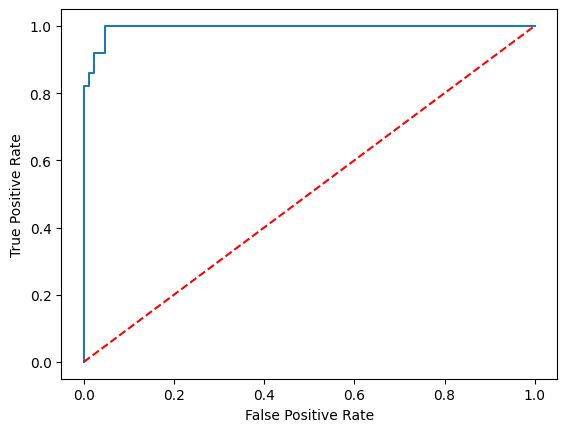

In [46]:
plt.plot(fpr,tpr,label='ROC curve (area = %0.2f)'%roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0,1],[0,1], color='red',linestyle='--') #Random classifier

plt.show()

In [47]:
#giảm FP bằng cách tăng ngưỡng thresholds lên
new_thresholds = 0.7 #mặc định 0.5
y_pred_new = (y_prob >= new_thresholds).astype(int)

cm_new = confusion_matrix(y_test,y_pred_new)
print(cm_new)


[[85  2]
 [ 7 43]]
